# ¿Cuánto se gana en México? El salario que registra el IMSS, 2018 a 2026

Las vacantes no dicen cuánto pagan, pero el IMSS registra el salario base de cotización de 22.8 millones de puestos de trabajo. Aquí se comparan cinco cortes de agosto, de 2018 a 2026, para responder cuánto se gana, cómo se reparte, en qué estados y sectores, y qué tan lejos quedó el salario mínimo del promedio.

**Fuente:** Datos Abiertos IMSS, cortes del 31 de agosto, agregados por el notebook 01 (`data/manifest.json`). Salario mínimo general diario de la CONASAMI. Pesos corrientes.

## 0. El salario mínimo se acercó al promedio y a la mediana

El promedio que publica el IMSS es una cota inferior, porque el salario base de cotización está topado a 25 UMA (sección 1). Por eso aquí se calcula también la mediana y los cuartiles desde los rangos salariales, que el tope no toca.

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib_inline
import pandas as pd
from matplotlib import font_manager as fm

matplotlib_inline.backend_inline.set_matplotlib_formats("retina")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA = RAIZ / "data"
SALARIO_MINIMO = {2018: 88.36, 2020: 123.22, 2022: 172.87, 2024: 248.93, 2026: 315.04}
UMA = {2018: 80.60, 2020: 86.88, 2022: 96.22, 2024: 108.57, 2026: 117.31}
DIAS_MES = 30.4

PALETA = {
    "papel": "#050706", "panel": "#0B0F0D", "tinta": "#F3F1EC", "tenue": "#ACABA7", "leve": "#81817E",
    "filete": "#222321", "filete_fuerte": "#393A38", "verde": "#00DF81", "verde_hondo": "#00C271",
    "neutro": "#646561", "neutro_claro": "#9A9A96",
}
# Archivo (póster) para los títulos y IBM Plex Mono para el pie, si están instaladas; el cuerpo va en DejaVu Sans
# porque la variable Outfit se dibuja en peso 100 en matplotlib.
for archivo in ["NyxArchivo-VF.ttf", "NyxIBMPlexMono-Regular.ttf"]:
    ruta = Path.home() / "Library" / "Fonts" / archivo
    if ruta.exists():
        fm.fontManager.addfont(str(ruta))
INSTALADAS = {f.name for f in fm.fontManager.ttflist}
ARCHIVO = "Archivo" if "Archivo" in INSTALADAS else "DejaVu Sans"
MONO = "IBM Plex Mono" if "IBM Plex Mono" in INSTALADAS else "DejaVu Sans Mono"
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 12,
    "figure.facecolor": PALETA["papel"], "axes.facecolor": PALETA["papel"], "savefig.facecolor": PALETA["papel"],
    "text.color": PALETA["tinta"], "axes.labelcolor": PALETA["tenue"],
    "xtick.color": PALETA["tenue"], "ytick.color": PALETA["tenue"],
    "axes.edgecolor": PALETA["filete_fuerte"], "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "axes.titlesize": 16, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 28,
    "figure.figsize": (12, 6.75), "figure.dpi": 100, "savefig.dpi": 150, "legend.frameon": False,
})


def leer(nombre: str) -> pd.DataFrame:
    return pd.read_csv(DATA / f"{nombre}.csv")


def titulo(ax, texto, size=16):
    # El signo de pesos se escapa: dos "$" en un texto activan el modo matemático de matplotlib.
    ax.set_title(texto.replace("$", r"\$"), fontsize=size, fontfamily=ARCHIVO, fontweight="bold")


def subtitulo(ax, texto):
    ax.text(0, 1.01, texto, transform=ax.transAxes, fontsize=11.5, color=PALETA["tenue"])


def pie(fig, texto="Fuente: Datos Abiertos IMSS, cortes del 31 de agosto · salario mínimo: CONASAMI · pesos corrientes · consulta 21 sep 2026"):
    fig.text(0.01, 0.005, texto, ha="left", va="bottom", fontsize=9, color=PALETA["leve"], fontfamily=MONO)

In [2]:
nacional = leer("nacional").set_index("anio")
nacional["sbc"] = nacional["masa_sal_ta"] / nacional["ta_sal"]
nacional["salario_minimo"] = pd.Series(SALARIO_MINIMO)
nacional["sbc_entre_minimo"] = nacional["sbc"] / nacional["salario_minimo"]
ULTIMO = int(nacional.index.max())

rangos = leer("rango_salarial").dropna(subset=["rango_salarial"])
rangos["w"] = rangos["rango_salarial"].str[1:].astype(int)
conteos = rangos.pivot_table(index="w", columns="anio", values="ta_sal", aggfunc="sum").fillna(0)


def percentil_agrupado(conteos_anio: pd.Series, p: float) -> float:
    """Percentil p en múltiplos del salario mínimo, interpolando dentro del rango W que lo contiene."""
    acumulado = conteos_anio.sort_index().cumsum() / conteos_anio.sum()
    k = acumulado[acumulado >= p].index[0]
    previo = acumulado.shift(1, fill_value=0.0)[k]
    return (k - 1) + (p - previo) / (acumulado[k] - previo)


for nombre, p in [("p25", 0.25), ("mediana", 0.5), ("p75", 0.75)]:
    nacional[nombre] = [percentil_agrupado(conteos[a], p) * SALARIO_MINIMO[a] for a in nacional.index]
nacional["mediana_entre_minimo"] = nacional["mediana"] / nacional["salario_minimo"]
print(f"SBC promedio {ULTIMO}: {nacional.loc[ULTIMO, 'sbc']:.1f} pesos diarios, {nacional.loc[ULTIMO, 'sbc'] * DIAS_MES:,.0f} al mes (cota inferior por el tope de 25 UMA)")
print(f"Mediana {ULTIMO}: {nacional.loc[ULTIMO, 'mediana']:.0f} pesos diarios, {nacional.loc[ULTIMO, 'mediana'] * DIAS_MES:,.0f} al mes · cuartiles {nacional.loc[ULTIMO, 'p25']:.0f} y {nacional.loc[ULTIMO, 'p75']:.0f}")
print(f"Crecimiento nominal 2018-{ULTIMO}: promedio +{100 * (nacional.loc[ULTIMO, 'sbc'] / nacional.loc[2018, 'sbc'] - 1):.0f} %, mediana +{100 * (nacional.loc[ULTIMO, 'mediana'] / nacional.loc[2018, 'mediana'] - 1):.0f} %, salario mínimo +{100 * (SALARIO_MINIMO[ULTIMO] / SALARIO_MINIMO[2018] - 1):.0f} %")
print("Promedio entre mínimo:", ", ".join(f"{a}: {v:.2f}x" for a, v in nacional["sbc_entre_minimo"].items()))
print("Mediana entre mínimo: ", ", ".join(f"{a}: {v:.2f}x" for a, v in nacional["mediana_entre_minimo"].items()))
nacional[["ta", "sbc", "mediana", "p25", "p75", "salario_minimo", "sbc_entre_minimo", "mediana_entre_minimo"]].round(2)

SBC promedio 2026: 673.1 pesos diarios, 20,461 al mes (cota inferior por el tope de 25 UMA)
Mediana 2026: 542 pesos diarios, 16,477 al mes · cuartiles 425 y 766
Crecimiento nominal 2018-2026: promedio +89 %, mediana +145 %, salario mínimo +257 %
Promedio entre mínimo: 2018: 4.03x, 2020: 3.28x, 2022: 2.80x, 2024: 2.36x, 2026: 2.14x
Mediana entre mínimo:  2018: 2.50x, 2020: 2.03x, 2022: 1.89x, 2024: 1.79x, 2026: 1.72x


,ta,sbc,mediana,p25,p75,salario_minimo,sbc_entre_minimo,mediana_entre_minimo
anio,,,,,,,,
2018,20063433,356.15,221.33,142.99,415.51,88.36,4.03,2.50
2020,19588342,404.13,249.62,185.24,469.07,123.22,3.28,2.03
2022,21236866,484.34,327.47,249.85,555.82,172.87,2.80,1.89
2024,22389835,587.46,444.95,345.21,674.61,248.93,2.36,1.79
2026,22798473,673.05,542.01,424.61,765.81,315.04,2.14,1.72


In [3]:
GRUPOS = [("Hasta 1 salario mínimo", 1, 1), ("Más de 1 y hasta 2", 2, 2), ("Más de 2 y hasta 3", 3, 3), ("Más de 3 y hasta 5", 4, 5), ("Más de 5", 6, 25)]
def grupo(w):
    for nombre, lo, hi in GRUPOS:
        if lo <= w <= hi:
            return nombre
rangos["grupo"] = rangos["w"].map(grupo)
distribucion = rangos.groupby(["anio", "grupo"])["ta_sal"].sum().unstack()[[g[0] for g in GRUPOS]]
distribucion = 100 * distribucion.div(distribucion.sum(axis=1), axis=0)
print(f"Puestos que ganan hasta 2 salarios mínimos: 2018 = {distribucion.loc[2018].iloc[:2].sum():.1f} %, {ULTIMO} = {distribucion.loc[ULTIMO].iloc[:2].sum():.1f} %")
print(f"Puestos que ganan más de 5 salarios mínimos: 2018 = {distribucion.loc[2018, 'Más de 5']:.1f} %, {ULTIMO} = {distribucion.loc[ULTIMO, 'Más de 5']:.1f} %")
distribucion.round(1)

Puestos que ganan hasta 2 salarios mínimos: 2018 = 40.4 %, 2026 = 68.8 %
Puestos que ganan más de 5 salarios mínimos: 2018 = 23.0 %, 2026 = 7.1 %


grupo,Hasta 1 salario mínimo,Más de 1 y hasta 2,Más de 2 y hasta 3,Más de 3 y hasta 5,Más de 5
anio,,,,,
2018,0.1,40.3,19.0,17.6,23.0
2020,0.1,49.4,17.9,15.7,16.8
2022,0.2,55.7,17.1,14.4,12.6
2024,0.9,62.4,16.5,11.4,8.8
2026,1.7,67.1,14.5,9.6,7.1


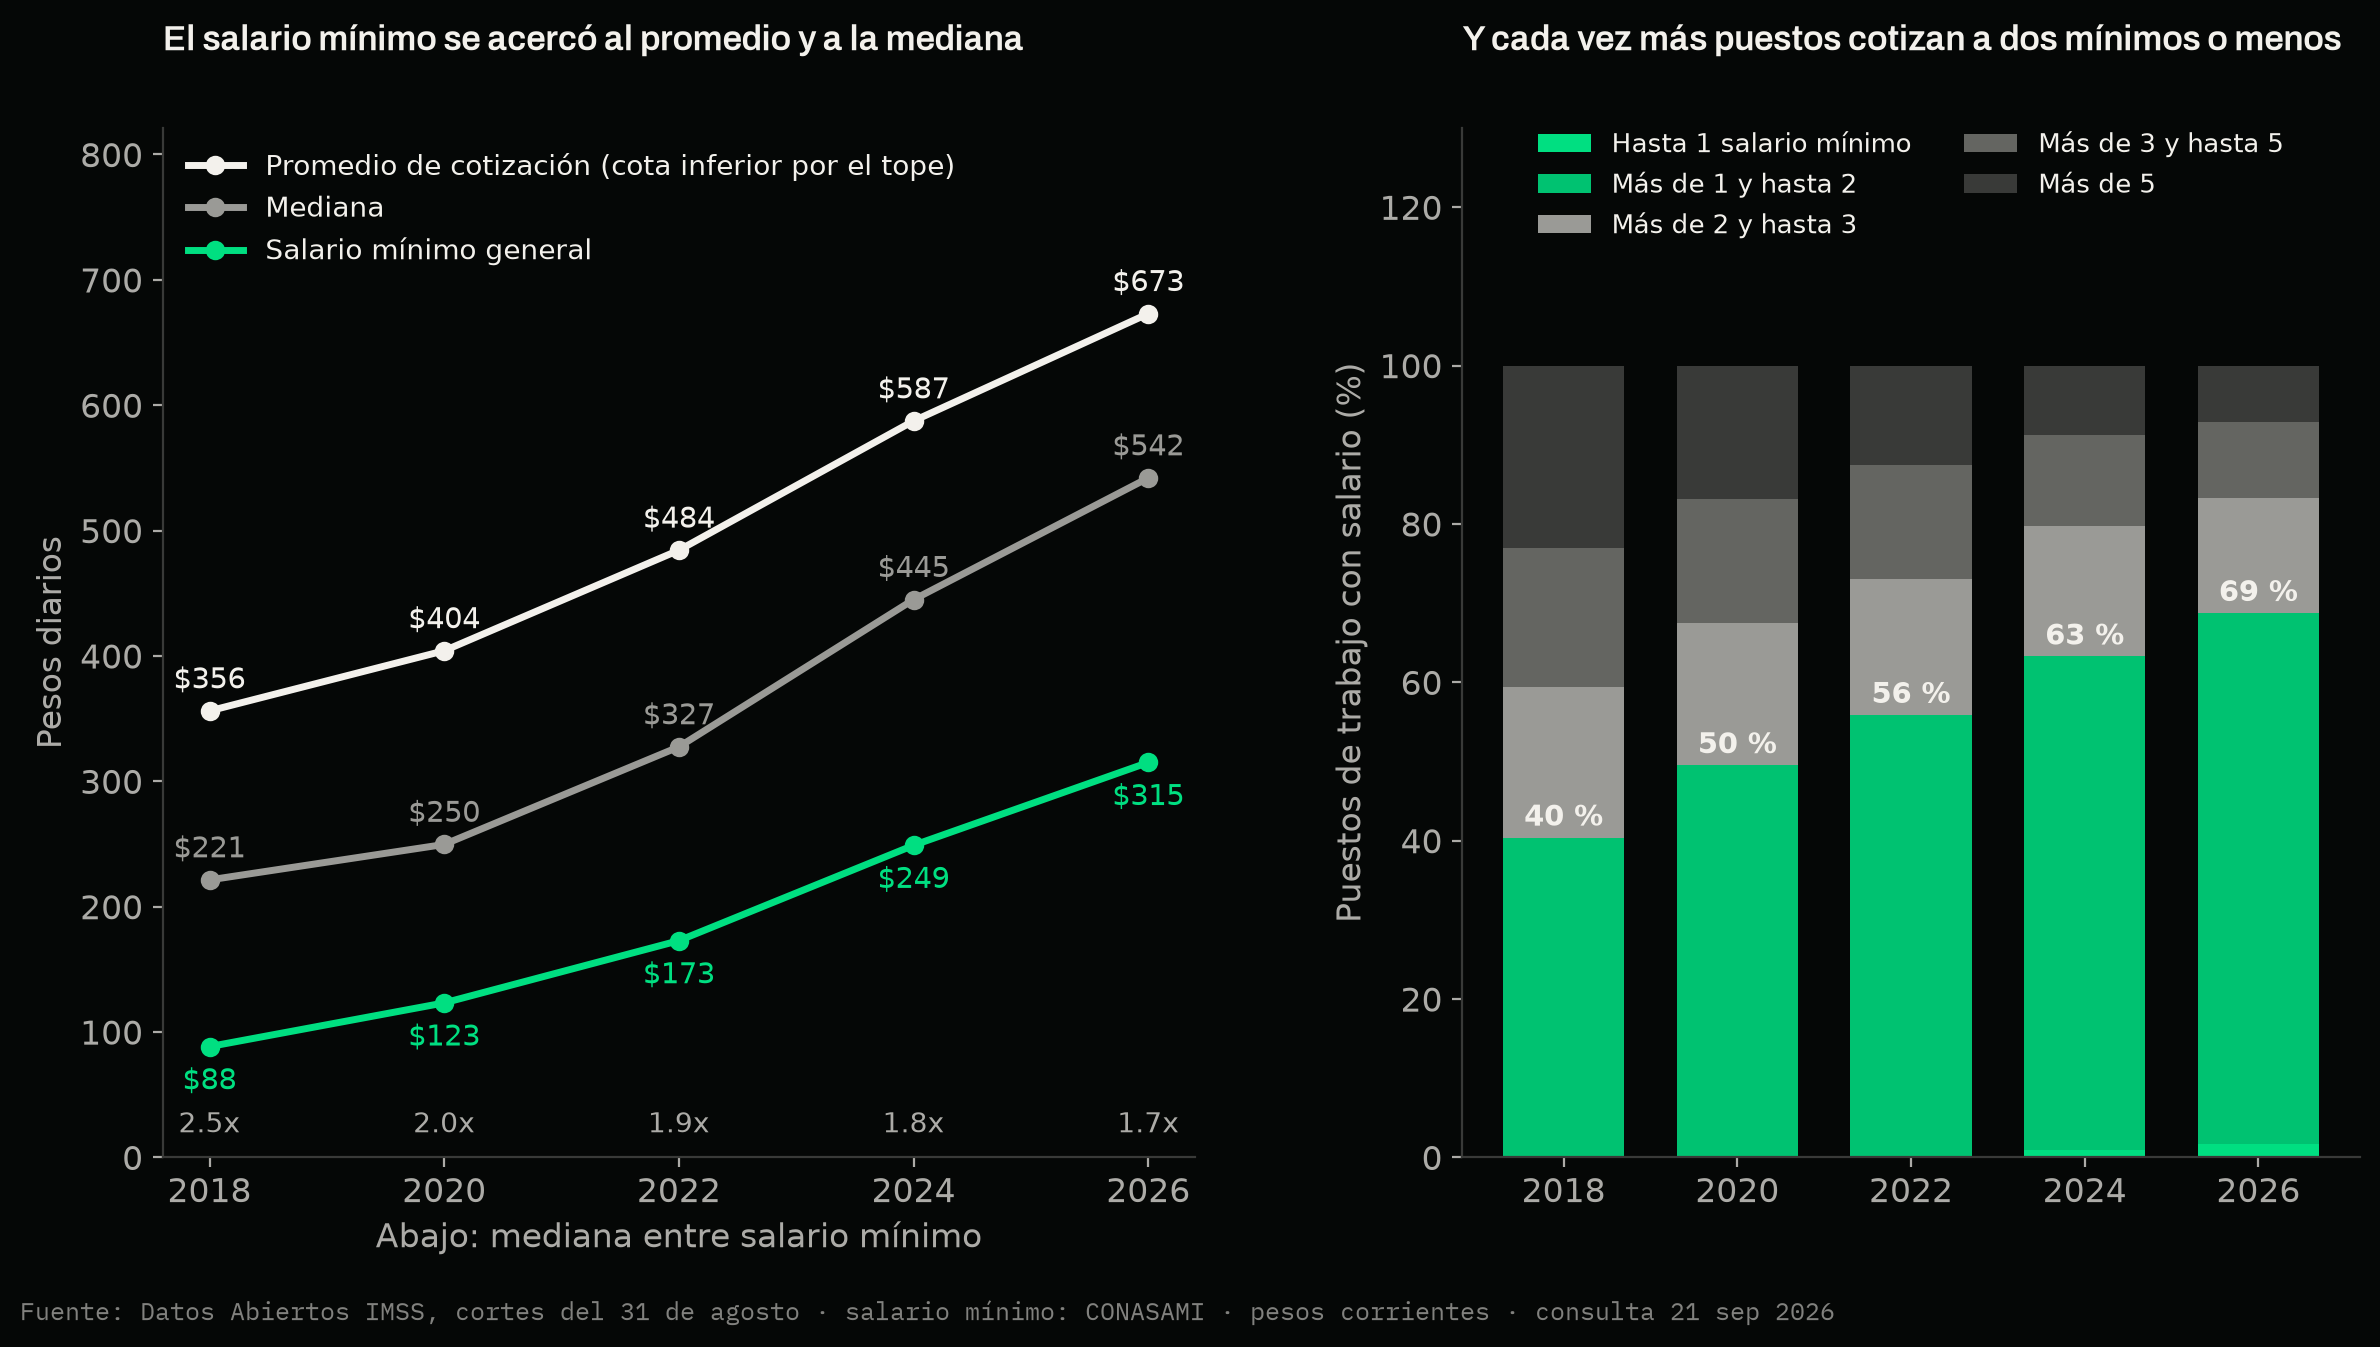

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 6.75), gridspec_kw={"width_ratios": [1.15, 1]})
anios = list(nacional.index)
a1.plot(anios, nacional["sbc"], color=PALETA["tinta"], linewidth=2.5, marker="o", label="Promedio de cotización (cota inferior por el tope)")
a1.plot(anios, nacional["mediana"], color=PALETA["neutro_claro"], linewidth=2.5, marker="o", label="Mediana")
a1.plot(anios, nacional["salario_minimo"], color=PALETA["verde"], linewidth=2.5, marker="o", label="Salario mínimo general")
for a in anios:
    a1.text(a, nacional.loc[a, "sbc"] + 18, f"${nacional.loc[a, 'sbc']:.0f}", ha="center", fontsize=10.5, color=PALETA["tinta"])
    a1.text(a, nacional.loc[a, "mediana"] + 18, f"${nacional.loc[a, 'mediana']:.0f}", ha="center", fontsize=10.5, color=PALETA["neutro_claro"])
    a1.text(a, nacional.loc[a, "salario_minimo"] - 34, f"${nacional.loc[a, 'salario_minimo']:.0f}", ha="center", fontsize=10.5, color=PALETA["verde"])
    a1.text(a, 20, f"{nacional.loc[a, 'mediana_entre_minimo']:.1f}x", ha="center", fontsize=10, color=PALETA["tenue"])
a1.set_ylim(0, nacional["sbc"].max() * 1.22)
a1.set_xticks(anios)
a1.set_ylabel("Pesos diarios")
a1.set_xlabel("Abajo: mediana entre salario mínimo")
titulo(a1, "El salario mínimo se acercó al promedio y a la mediana", 12.5)
a1.legend(loc="upper left", fontsize=10)
colores = [PALETA["verde"], PALETA["verde_hondo"], PALETA["neutro_claro"], PALETA["neutro"], PALETA["filete_fuerte"]]
abajo = pd.Series(0.0, index=distribucion.index)
for (nombre, _, _), color in zip(GRUPOS, colores):
    a2.bar(distribucion.index.astype(str), distribucion[nombre], bottom=abajo.values, color=color, label=nombre, width=0.7)
    abajo = abajo + distribucion[nombre]
for a in distribucion.index:
    hasta2 = distribucion.loc[a].iloc[:2].sum()
    a2.text(str(a), hasta2 + 1.5, f"{hasta2:.0f} %", ha="center", fontsize=10.5, color=PALETA["tinta"], fontweight="bold")
a2.set_ylim(0, 130)
a2.set_ylabel("Puestos de trabajo con salario (%)")
titulo(a2, "Y cada vez más puestos cotizan a dos mínimos o menos", 12.5)
a2.legend(loc="upper center", ncol=2, fontsize=9.5, bbox_to_anchor=(0.5, 1.02))
pie(fig)
plt.tight_layout(rect=(0, 0.03, 1, 1), w_pad=4)
plt.show()

## 1. El tope de 25 UMA: por qué el promedio es una cota inferior

La Ley del Seguro Social limita el salario base de cotización a 25 veces la UMA. Quien gana más cotiza el tope y aparece en el rango `W25` de `rango_uma`: son pocos puestos, pero cargan una décima parte de la masa salarial, y lo que ganan por arriba del tope no existe en el registro. Por eso el promedio que publica el IMSS, y el de este notebook, es una cota inferior. La mediana y los cuartiles no dependen del tope: en 2026 el tope equivale a 9.3 salarios mínimos y tres de cada cuatro puestos cotizan menos de 3.

In [5]:
uma = leer("rango_uma")
totales_uma = uma.groupby("anio")[["ta_sal", "masa_sal_ta"]].sum()
topados = uma[uma.rango_uma == "W25"].groupby("anio")[["ta_sal", "masa_sal_ta"]].sum()
por_uma = pd.DataFrame({
    "puestos_topados": topados["ta_sal"],
    "pct_puestos": 100 * topados["ta_sal"] / totales_uma["ta_sal"],
    "pct_masa": 100 * topados["masa_sal_ta"] / totales_uma["masa_sal_ta"],
})
por_uma["tope_pesos"] = [25 * UMA[a] for a in por_uma.index]
por_uma["tope_en_minimos"] = por_uma["tope_pesos"] / pd.Series(SALARIO_MINIMO)
print(f"Topados {ULTIMO}: {por_uma.loc[ULTIMO, 'puestos_topados']:,.0f} puestos, {por_uma.loc[ULTIMO, 'pct_puestos']:.1f} % de los puestos y {por_uma.loc[ULTIMO, 'pct_masa']:.1f} % de la masa salarial · tope {por_uma.loc[ULTIMO, 'tope_pesos']:,.0f} pesos diarios = {por_uma.loc[ULTIMO, 'tope_en_minimos']:.1f} salarios mínimos")
por_uma.round(2)

Topados 2026: 526,570 puestos, 2.3 % de los puestos y 10.1 % de la masa salarial · tope 2,933 pesos diarios = 9.3 salarios mínimos


,puestos_topados,pct_puestos,pct_masa,tope_pesos,tope_en_minimos
anio,,,,,
2018,371711,1.87,10.54,2015.00,22.80
2020,381764,1.96,10.52,2172.00,17.63
2022,462845,2.19,10.87,2405.50,13.92
2024,487251,2.19,10.08,2714.25,10.90
2026,526570,2.32,10.07,2932.75,9.31


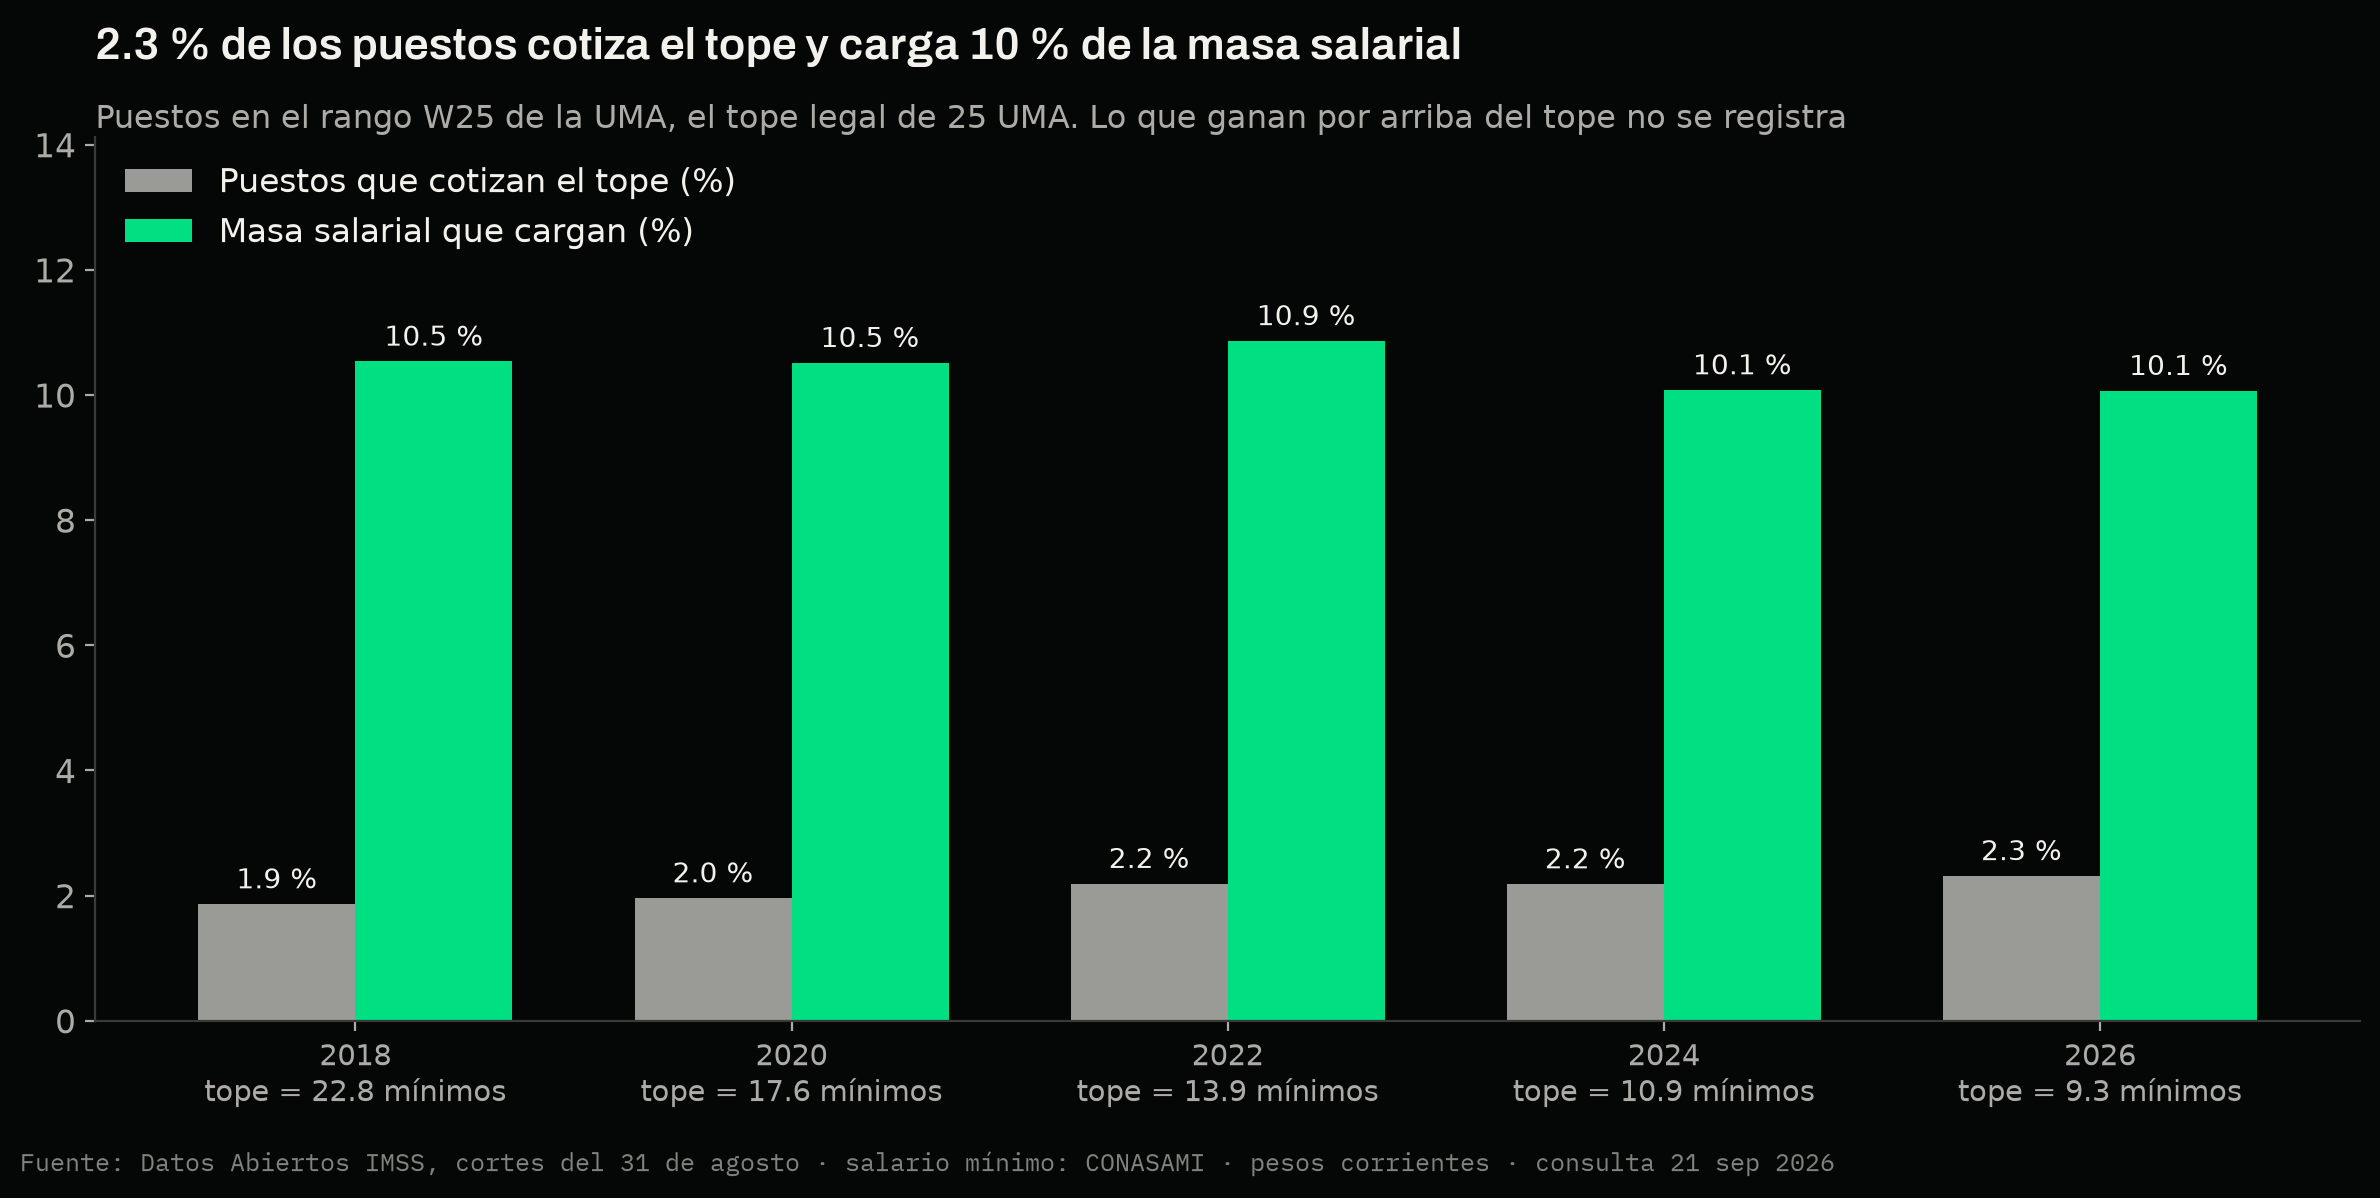

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
x = list(range(len(por_uma)))
ancho = 0.36
ax.bar([i - ancho / 2 for i in x], por_uma["pct_puestos"], width=ancho, color=PALETA["neutro_claro"], label="Puestos que cotizan el tope (%)")
ax.bar([i + ancho / 2 for i in x], por_uma["pct_masa"], width=ancho, color=PALETA["verde"], label="Masa salarial que cargan (%)")
for i, a in enumerate(por_uma.index):
    ax.text(i - ancho / 2, por_uma.loc[a, "pct_puestos"] + 0.25, f"{por_uma.loc[a, 'pct_puestos']:.1f} %", ha="center", fontsize=10, color=PALETA["tinta"])
    ax.text(i + ancho / 2, por_uma.loc[a, "pct_masa"] + 0.25, f"{por_uma.loc[a, 'pct_masa']:.1f} %", ha="center", fontsize=10, color=PALETA["tinta"])
ax.set_xticks(x, [f"{a}\ntope = {por_uma.loc[a, 'tope_en_minimos']:.1f} mínimos" for a in por_uma.index])
ax.tick_params(axis="x", labelsize=10.5)
ax.set_ylim(0, por_uma["pct_masa"].max() * 1.3)
titulo(ax, f"{por_uma.loc[ULTIMO, 'pct_puestos']:.1f} % de los puestos cotiza el tope y carga {por_uma.loc[ULTIMO, 'pct_masa']:.0f} % de la masa salarial")
subtitulo(ax, "Puestos en el rango W25 de la UMA, el tope legal de 25 UMA. Lo que ganan por arriba del tope no se registra")
ax.legend(loc="upper left")
pie(fig)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

## 2. Por estado: dónde se paga más y quién subió más

Salario promedio de cotización por entidad del registro patronal, agosto de 2026, y su cambio nominal desde 2018.

In [7]:
ent = leer("entidad_sexo")
por_entidad = ent.groupby(["anio", "entidad"])[["ta_sal", "masa_sal_ta"]].sum()
por_entidad["sbc"] = por_entidad["masa_sal_ta"] / por_entidad["ta_sal"]
sbc_ent = por_entidad["sbc"].unstack(0)
sbc_ent["cambio_%"] = 100 * (sbc_ent[ULTIMO] / sbc_ent[2018] - 1)
sbc_ent = sbc_ent.sort_values(ULTIMO, ascending=False)
nac = nacional.loc[ULTIMO, "sbc"]
print(f"Mayor SBC {ULTIMO}: {sbc_ent.index[0]} ${sbc_ent[ULTIMO].iloc[0]:.0f} · menor: {sbc_ent.index[-1]} ${sbc_ent[ULTIMO].iloc[-1]:.0f} · cociente {sbc_ent[ULTIMO].iloc[0] / sbc_ent[ULTIMO].iloc[-1]:.2f}x")
print(f"Estados por arriba del promedio nacional (${nac:.0f}): {(sbc_ent[ULTIMO] > nac).sum()} de {len(sbc_ent)}")
mas = sbc_ent["cambio_%"].idxmax()
menos = sbc_ent["cambio_%"].idxmin()
print(f"Mayor crecimiento 2018-{ULTIMO}: {mas} +{sbc_ent.loc[mas, 'cambio_%']:.0f} % · menor: {menos} +{sbc_ent.loc[menos, 'cambio_%']:.0f} %")
sbc_ent.round(1)

Mayor SBC 2026: Ciudad de México $801 · menor: Nayarit $537 · cociente 1.49x
Estados por arriba del promedio nacional ($673): 9 de 32
Mayor crecimiento 2018-2026: Quintana Roo +129 % · menor: Morelos +73 %


anio,2018,2020,2022,2024,2026,cambio_%
entidad,,,,,,
Ciudad de México,445.5,503.8,612.6,724.4,800.9,79.8
Baja California,348.5,418.2,522.7,666.3,739.9,112.3
Nuevo León,394.1,439.7,530.7,638.6,737.3,87.1
Querétaro,400.2,441.4,525.5,637.4,732.0,82.9
Campeche,394.7,450.8,544.0,644.7,707.0,79.1
Tamaulipas,333.8,391.2,480.0,609.0,703.9,110.8
Chihuahua,340.0,394.8,481.7,605.1,696.9,105.0
San Luis Potosí,361.3,424.0,495.9,600.0,686.0,89.9
Coahuila de Zaragoza,355.2,404.2,479.7,591.6,678.6,91.0


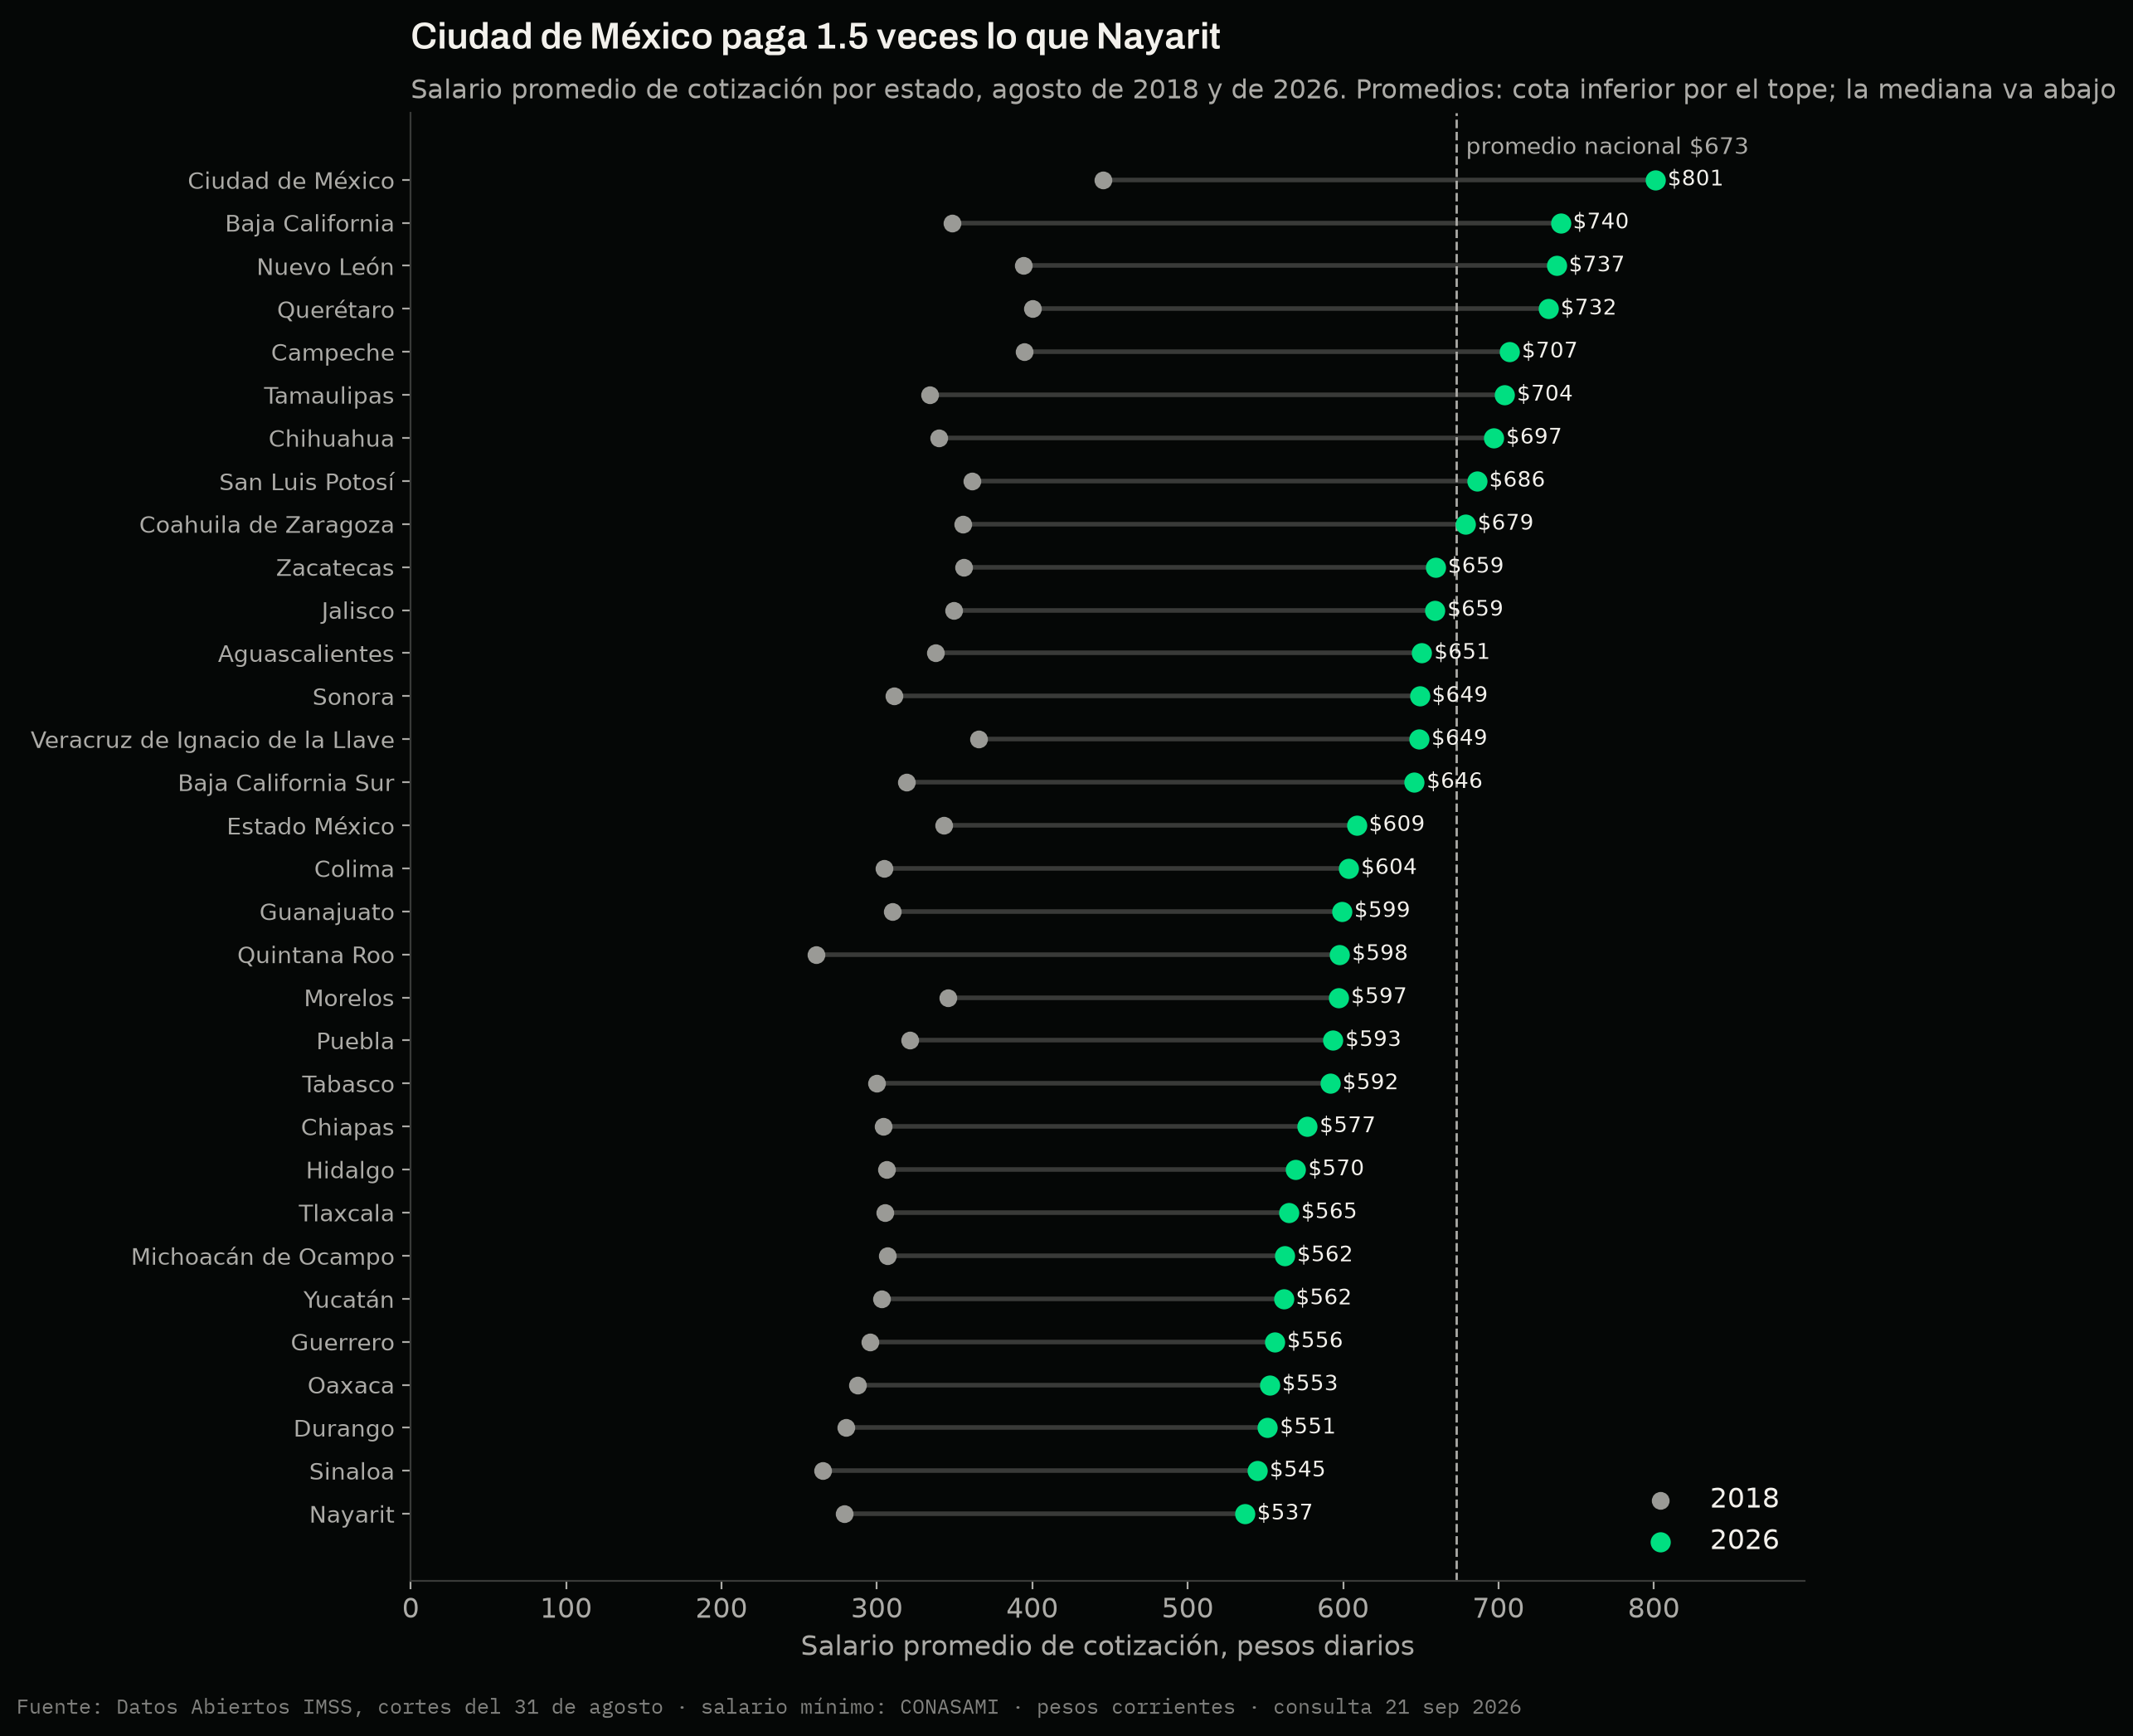

In [8]:
orden = sbc_ent.index[::-1]
fig, ax = plt.subplots(figsize=(12, 10.5))
y = range(len(orden))
ax.hlines(list(y), sbc_ent.loc[orden, 2018], sbc_ent.loc[orden, ULTIMO], color=PALETA["filete_fuerte"], linewidth=2)
ax.scatter(sbc_ent.loc[orden, 2018], list(y), color=PALETA["neutro_claro"], s=45, zorder=3, label="2018")
ax.scatter(sbc_ent.loc[orden, ULTIMO], list(y), color=PALETA["verde"], s=60, zorder=4, label=str(ULTIMO))
for i, e in enumerate(orden):
    ax.text(sbc_ent.loc[e, ULTIMO] + 8, i, f"${sbc_ent.loc[e, ULTIMO]:.0f}", va="center", fontsize=9.5, color=PALETA["tinta"])
ax.axvline(nac, color=PALETA["tenue"], linestyle="--", linewidth=1)
ax.text(nac + 6, len(orden) - 0.4, f"promedio nacional ${nac:.0f}", fontsize=10, color=PALETA["tenue"])
ax.set_yticks(list(y), orden)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlim(0, sbc_ent[ULTIMO].max() * 1.12)
ax.set_xlabel("Salario promedio de cotización, pesos diarios")
titulo(ax, f"{sbc_ent.index[0]} paga {sbc_ent[ULTIMO].iloc[0] / sbc_ent[ULTIMO].iloc[-1]:.1f} veces lo que {sbc_ent.index[-1]}")
subtitulo(ax, f"Salario promedio de cotización por estado, agosto de 2018 y de {ULTIMO}. Promedios: cota inferior por el tope; la mediana va abajo")
ax.legend(loc="lower right")
pie(fig)
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.show()

Con el tope a la vista, la comparación honesta entre estados es la mediana, que no depende de él. También cambia quién parece pagar más: donde hay más puestos topados, el promedio subestima más.

In [9]:
er = leer("entidad_rango").dropna(subset=["rango_salarial"])
er["w"] = er["rango_salarial"].str[1:].astype(int)
mediana_ent = {e: percentil_agrupado(d.groupby("w")["ta_sal"].sum(), 0.5) * SALARIO_MINIMO[ULTIMO] for e, d in er[er.anio == ULTIMO].groupby("entidad")}
eu = leer("entidad_uma")
eu_ultimo = eu[eu.anio == ULTIMO]
topados_ent = 100 * eu_ultimo[eu_ultimo.rango_uma == "W25"].groupby("entidad")["ta_sal"].sum() / eu_ultimo.groupby("entidad")["ta_sal"].sum()
comparativo = pd.DataFrame({"promedio": sbc_ent[ULTIMO], "mediana": pd.Series(mediana_ent), "pct_topados": topados_ent}).sort_values("mediana", ascending=False)
comparativo["promedio_entre_mediana"] = comparativo["promedio"] / comparativo["mediana"]
print(f"Mediana más alta {ULTIMO}: {comparativo.index[0]} ${comparativo['mediana'].iloc[0]:.0f} · más baja: {comparativo.index[-1]} ${comparativo['mediana'].iloc[-1]:.0f} · cociente {comparativo['mediana'].iloc[0] / comparativo['mediana'].iloc[-1]:.2f}x")
print(f"Más puestos topados: {comparativo['pct_topados'].idxmax()} {comparativo['pct_topados'].max():.1f} % · mayor cociente promedio/mediana: {comparativo['promedio_entre_mediana'].idxmax()} {comparativo['promedio_entre_mediana'].max():.2f}x · menor: {comparativo['promedio_entre_mediana'].idxmin()} {comparativo['promedio_entre_mediana'].min():.2f}x")
comparativo.round(2)

Mediana más alta 2026: Tamaulipas $578 · más baja: Guerrero $504 · cociente 1.15x
Más puestos topados: Ciudad de México 5.4 % · mayor cociente promedio/mediana: Ciudad de México 1.42x · menor: Nayarit 1.06x


,promedio,mediana,pct_topados,promedio_entre_mediana
Tamaulipas,703.87,578.38,1.29,1.22
Nuevo León,737.27,566.44,3.13,1.30
Ciudad de México,800.86,564.09,5.37,1.42
Querétaro,731.99,562.59,2.93,1.30
Baja California,739.90,562.48,2.03,1.32
Chihuahua,696.89,558.79,1.56,1.25
San Luis Potosí,686.00,556.11,1.88,1.23
Coahuila de Zaragoza,678.57,553.00,1.66,1.23
Campeche,707.01,549.17,2.84,1.29
Veracruz de Ignacio de la Llave,648.83,545.09,1.09,1.19


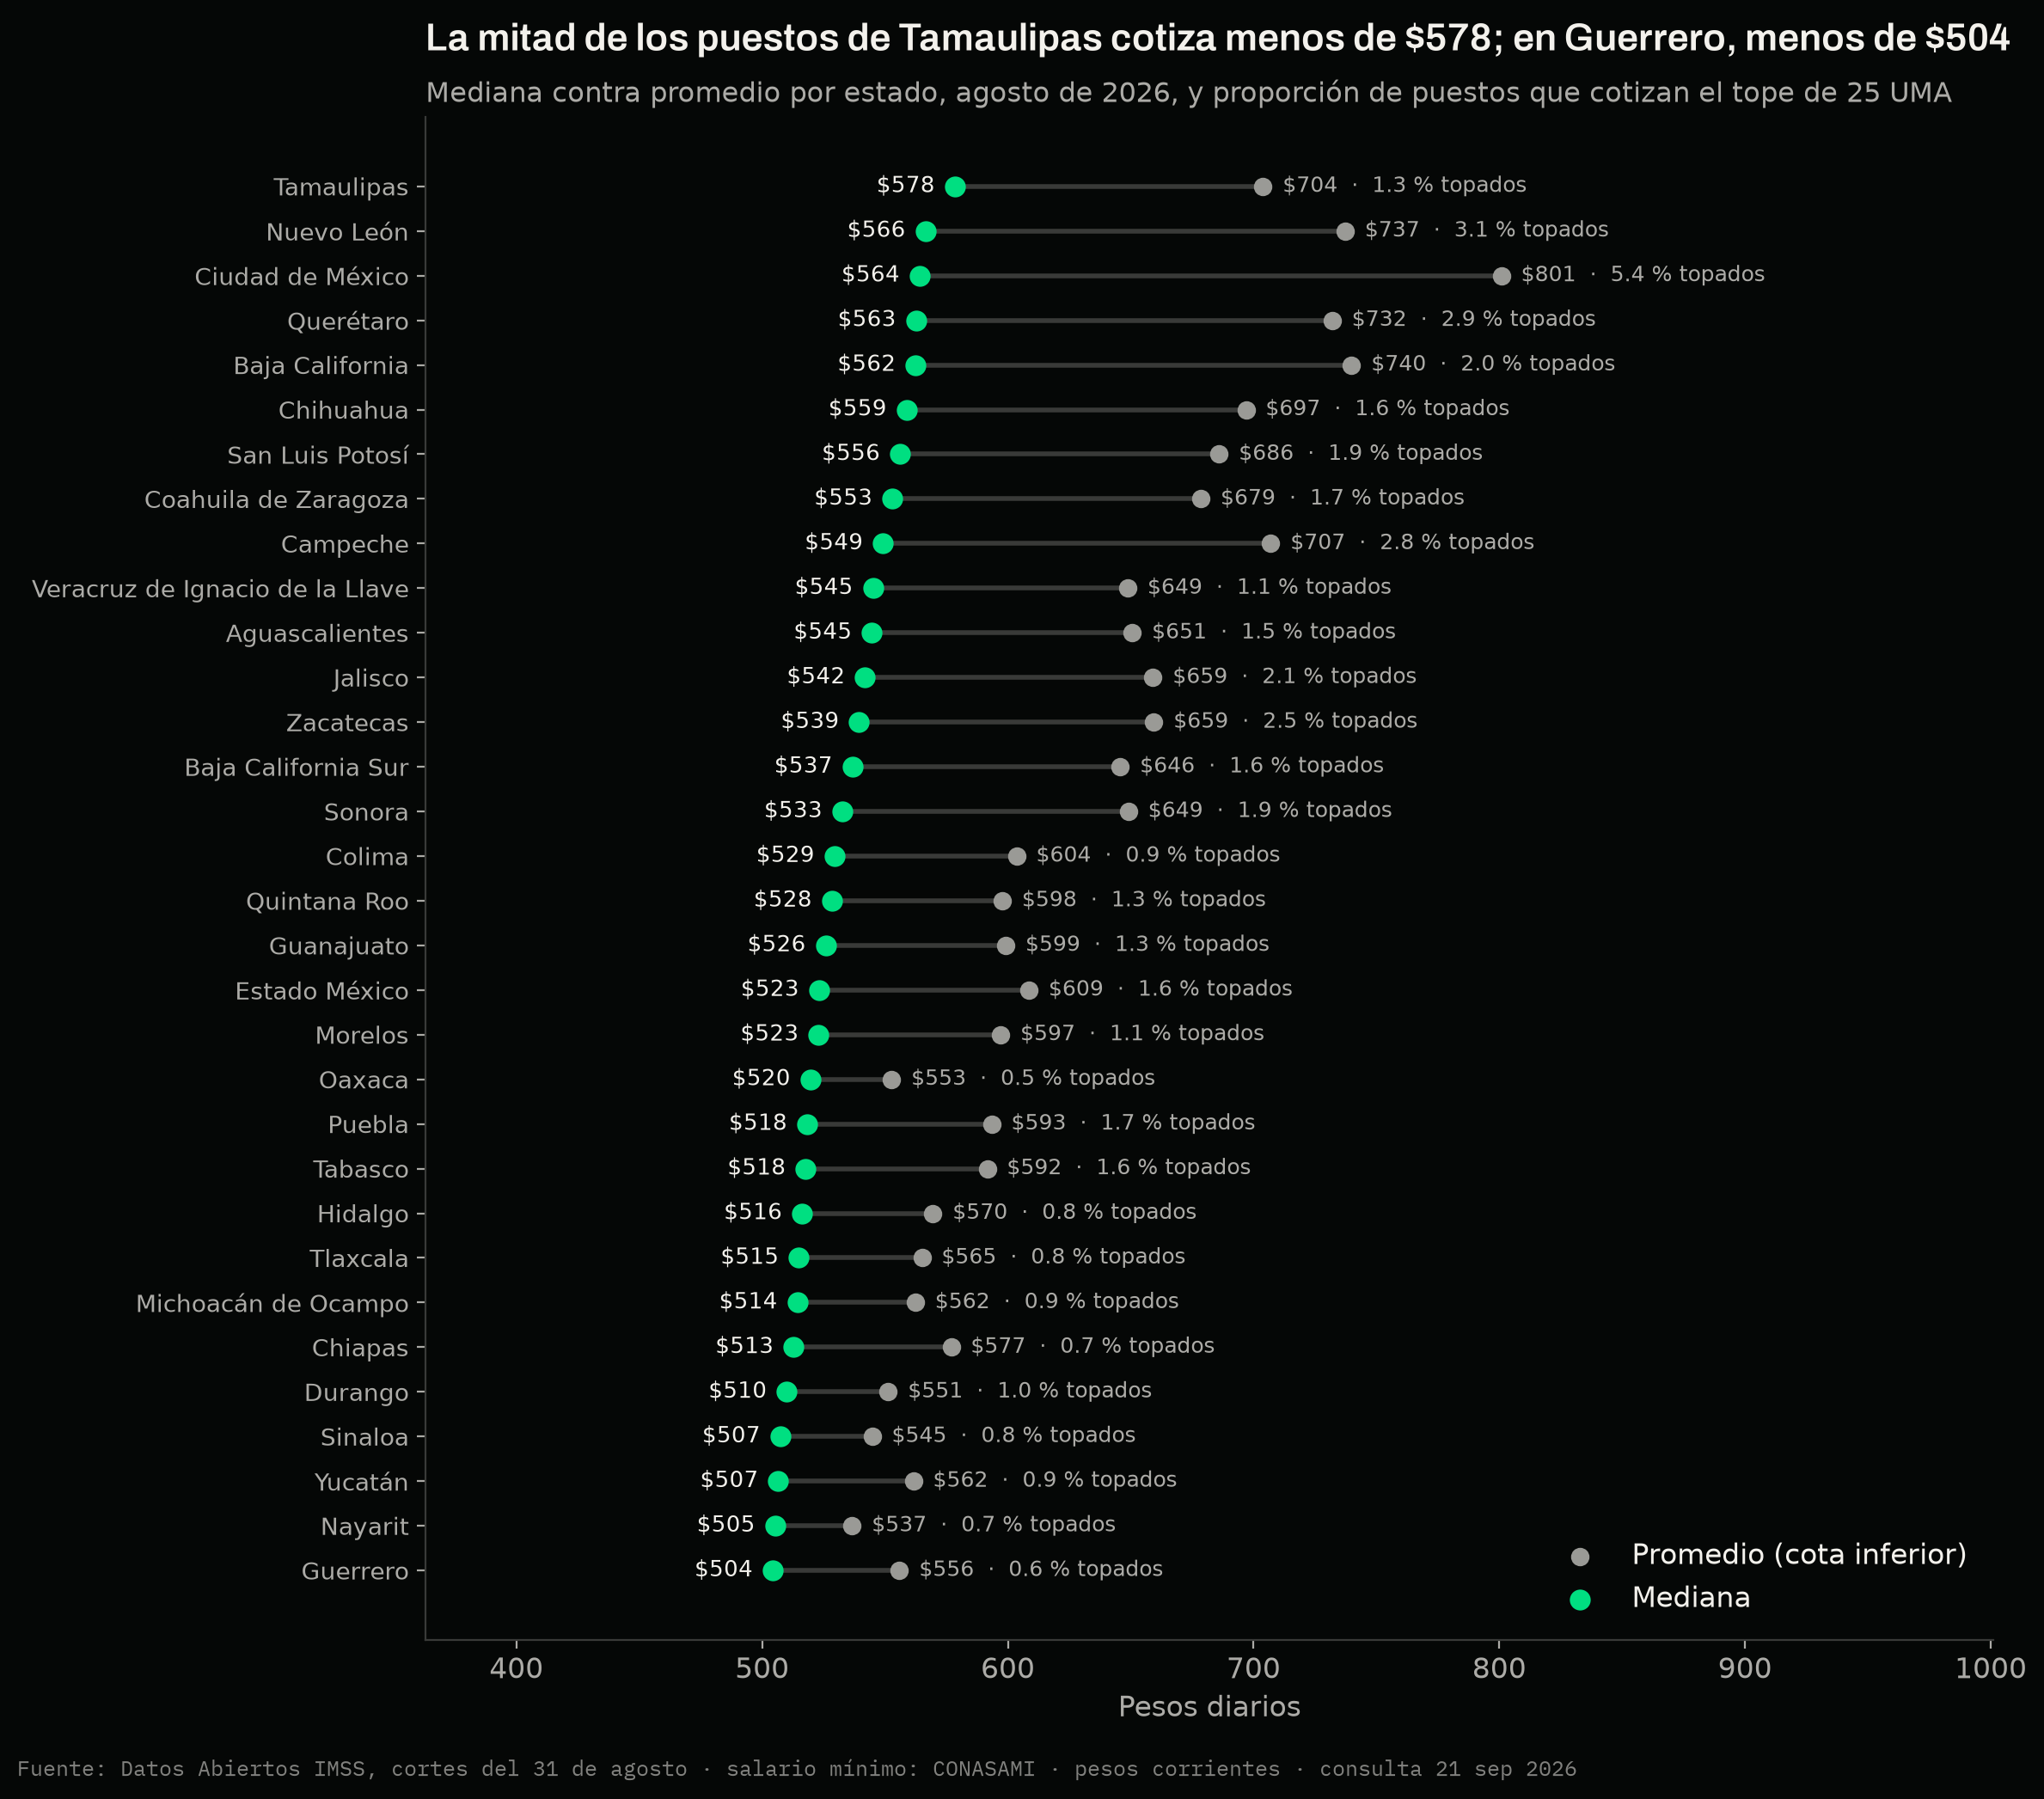

In [10]:
orden = comparativo.index[::-1]
fig, ax = plt.subplots(figsize=(12, 10.5))
y = range(len(orden))
ax.hlines(list(y), comparativo.loc[orden, "mediana"], comparativo.loc[orden, "promedio"], color=PALETA["filete_fuerte"], linewidth=2)
ax.scatter(comparativo.loc[orden, "promedio"], list(y), color=PALETA["neutro_claro"], s=45, zorder=3, label="Promedio (cota inferior)")
ax.scatter(comparativo.loc[orden, "mediana"], list(y), color=PALETA["verde"], s=60, zorder=4, label="Mediana")
for i, e in enumerate(orden):
    ax.text(comparativo.loc[e, "promedio"] + 8, i, f"${comparativo.loc[e, 'promedio']:.0f}  ·  {comparativo.loc[e, 'pct_topados']:.1f} % topados", va="center", fontsize=9, color=PALETA["tenue"])
    ax.text(comparativo.loc[e, "mediana"] - 8, i, f"${comparativo.loc[e, 'mediana']:.0f}", va="center", ha="right", fontsize=9.5, color=PALETA["tinta"])
ax.set_yticks(list(y), orden)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlim(comparativo["mediana"].min() * 0.72, comparativo["promedio"].max() * 1.25)
ax.set_xlabel("Pesos diarios")
titulo(ax, f"La mitad de los puestos de {comparativo.index[0]} cotiza menos de ${comparativo['mediana'].iloc[0]:.0f}; en {comparativo.index[-1]}, menos de ${comparativo['mediana'].iloc[-1]:.0f}")
subtitulo(ax, f"Mediana contra promedio por estado, agosto de {ULTIMO}, y proporción de puestos que cotizan el tope de 25 UMA")
ax.legend(loc="lower right")
pie(fig)
plt.tight_layout(rect=(0, 0.02, 1, 1))
plt.show()

## 3. La brecha entre mujeres y hombres

Cociente del salario promedio de las mujeres entre el de los hombres. Nacional por año y por estado en el último corte.

In [11]:
sexo = ent.groupby(["anio", "sexo"])[["ta_sal", "masa_sal_ta"]].sum()
sexo["sbc"] = sexo["masa_sal_ta"] / sexo["ta_sal"]
brecha = (sexo["sbc"].unstack()[2] / sexo["sbc"].unstack()[1]).rename("mujer_entre_hombre")
por_ent_sexo = ent[ent.anio == ULTIMO].groupby(["entidad", "sexo"])[["ta_sal", "masa_sal_ta"]].sum()
por_ent_sexo["sbc"] = por_ent_sexo["masa_sal_ta"] / por_ent_sexo["ta_sal"]
brecha_ent = (por_ent_sexo["sbc"].unstack()[2] / por_ent_sexo["sbc"].unstack()[1]).sort_values()
participacion_mujeres = 100 * sexo["ta_sal"].unstack()[2] / sexo["ta_sal"].unstack().sum(axis=1)
print("Mujer / hombre nacional:", ", ".join(f"{a}: {v:.3f}" for a, v in brecha.items()))
print(f"Mujeres en los puestos con salario: 2018 = {participacion_mujeres[2018]:.1f} %, {ULTIMO} = {participacion_mujeres[ULTIMO]:.1f} %")
print(f"Brecha más amplia {ULTIMO}: {brecha_ent.index[0]} ({brecha_ent.iloc[0]:.2f}) · más corta: {brecha_ent.index[-1]} ({brecha_ent.iloc[-1]:.2f})")
sr = leer("sexo_rango").dropna(subset=["rango_salarial"])
sr["w"] = sr["rango_salarial"].str[1:].astype(int)
med_sexo = {(a, s): percentil_agrupado(d.groupby("w")["ta_sal"].sum(), 0.5) * SALARIO_MINIMO[a] for (a, s), d in sr.groupby(["anio", "sexo"]) if s in (1, 2)}
brecha_mediana = pd.Series({a: med_sexo[(a, 2)] / med_sexo[(a, 1)] for a in sorted({a for a, _ in med_sexo})})
print("Mujer / hombre con medianas:", ", ".join(f"{a}: {v:.3f}" for a, v in brecha_mediana.items()), "(el tope pesa menos en la mediana)")
brecha_ent.round(3)

Mujer / hombre nacional: 2018: 0.870, 2020: 0.875, 2022: 0.866, 2024: 0.878, 2026: 0.893
Mujeres en los puestos con salario: 2018 = 37.4 %, 2026 = 40.4 %
Brecha más amplia 2026: Campeche (0.78) · más corta: Quintana Roo (0.97)
Mujer / hombre con medianas: 2018: 0.908, 2020: 0.906, 2022: 0.944, 2024: 0.951, 2026: 0.959 (el tope pesa menos en la mediana)


entidad
Campeche                           0.785
Coahuila de Zaragoza               0.816
Zacatecas                          0.817
Sonora                             0.840
Aguascalientes                     0.844
San Luis Potosí                    0.847
Guanajuato                         0.850
Querétaro                          0.852
Chihuahua                          0.863
Durango                            0.864
Puebla                             0.868
Colima                             0.870
Jalisco                            0.871
Hidalgo                            0.873
Nuevo León                         0.873
Estado México                      0.883
Baja California                    0.884
Michoacán de Ocampo                0.892
Guerrero                           0.895
Tamaulipas                         0.896
Tlaxcala                           0.907
Tabasco                            0.907
Oaxaca                             0.912
Sinaloa                            0.915
Morelos 

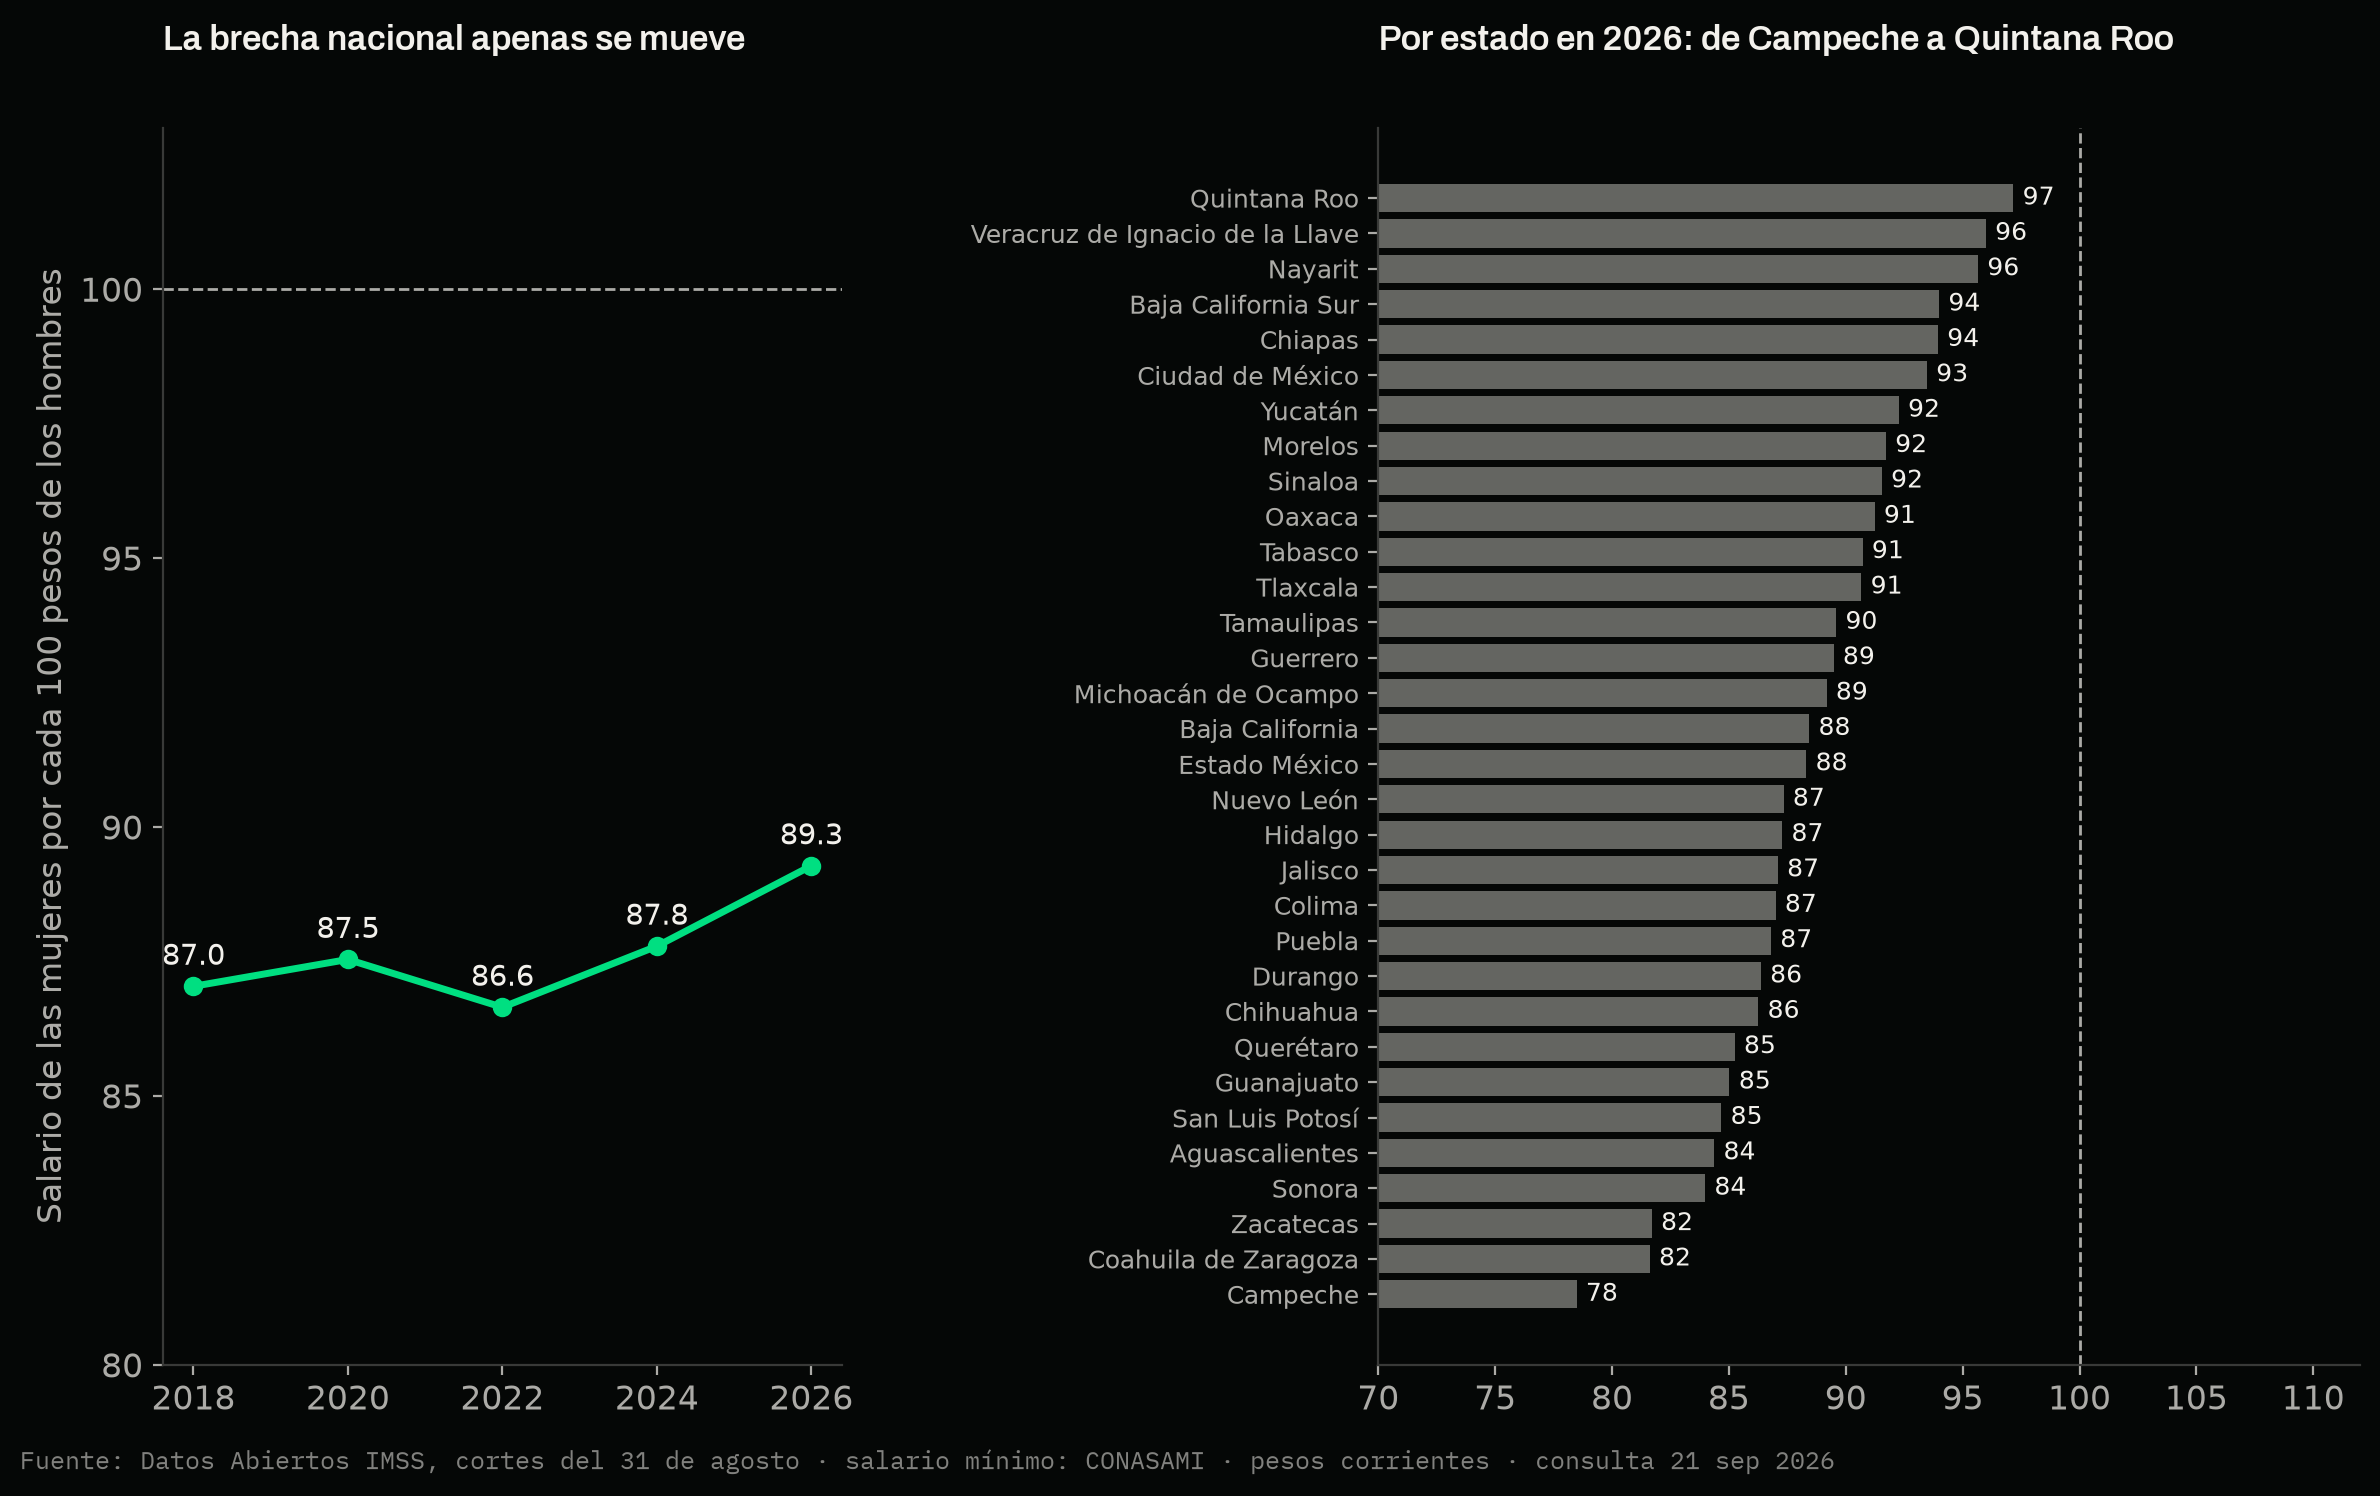

In [12]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 7.5), gridspec_kw={"width_ratios": [0.9, 1.3]})
a1.plot(list(brecha.index), 100 * brecha.values, color=PALETA["verde"], linewidth=2.5, marker="o")
for a, v in brecha.items():
    a1.text(a, 100 * v + 0.4, f"{100 * v:.1f}", ha="center", fontsize=10.5, color=PALETA["tinta"])
a1.axhline(100, color=PALETA["tenue"], linestyle="--", linewidth=1)
a1.set_ylim(min(100 * brecha.min() - 4, 80), 103)
a1.set_xticks(list(brecha.index))
a1.set_ylabel("Salario de las mujeres por cada 100 pesos de los hombres")
titulo(a1, "La brecha nacional apenas se mueve", 12.5)
b = brecha_ent
a2.barh(b.index, 100 * b.values, color=[PALETA["verde"] if v >= 1 else PALETA["neutro"] for v in b.values])
for i, v in enumerate(b.values):
    a2.text(100 * v + 0.4, i, f"{100 * v:.0f}", va="center", fontsize=9, color=PALETA["tinta"])
a2.axvline(100, color=PALETA["tenue"], linestyle="--", linewidth=1)
a2.set_xlim(min(100 * b.min() - 8, 70), 112)
a2.tick_params(axis="y", labelsize=9)
titulo(a2, f"Por estado en {ULTIMO}: de {b.index[0]} a {b.index[-1]}", 12.5)
pie(fig)
plt.tight_layout(rect=(0, 0.02, 1, 1), w_pad=3)
plt.show()

## 4. Sector y tamaño del patrón

Nueve divisiones de actividad y siete rangos de tamaño del registro patronal, agosto del último corte.

In [13]:
sec = leer("sector_sexo")
por_sector = sec[sec.anio == ULTIMO].groupby("sector")[["ta_sal", "masa_sal_ta"]].sum()
por_sector["sbc"] = por_sector["masa_sal_ta"] / por_sector["ta_sal"]
por_sector["puestos_%"] = 100 * por_sector["ta_sal"] / por_sector["ta_sal"].sum()
por_sector = por_sector.sort_values("sbc", ascending=False)
tam = leer("tamano_patron")
tam["tamano_patron"] = tam["tamano_patron"].str.strip().str.lower()
por_tam = tam[(tam.anio == ULTIMO) & tam.tamano_patron.notna()].groupby("tamano_patron")[["ta_sal", "masa_sal_ta"]].sum()
por_tam["sbc"] = por_tam["masa_sal_ta"] / por_tam["ta_sal"]
por_tam["puestos_%"] = 100 * por_tam["ta_sal"] / por_tam["ta_sal"].sum()
TAMANOS = {"s1": "1 puesto", "s2": "2 a 5", "s3": "6 a 50", "s4": "51 a 250", "s5": "251 a 500", "s6": "501 a 1,000", "s7": "más de 1,000"}
por_tam = por_tam.loc[[k for k in TAMANOS if k in por_tam.index]]
print(f"Sector mejor pagado: {por_sector.index[0]} ${por_sector['sbc'].iloc[0]:.0f} · peor: {por_sector.index[-1]} ${por_sector['sbc'].iloc[-1]:.0f}")
print(f"Patrones de más de 1,000 puestos: ${por_tam.loc['s7', 'sbc']:.0f} · de 2 a 5 puestos: ${por_tam.loc['s2', 'sbc']:.0f} · cociente {por_tam.loc['s7', 'sbc'] / por_tam.loc['s2', 'sbc']:.2f}x")
pd.concat([por_sector.round(1), por_tam.rename(index=TAMANOS).round(1)])

Sector mejor pagado: Ind Eléctrica y Captación y Suministro de Agua Potable $1305 · peor: Agricultura, Ganadería, Silvicultura, Pesca y Caza $485
Patrones de más de 1,000 puestos: $817 · de 2 a 5 puestos: $423 · cociente 1.93x


,ta_sal,masa_sal_ta,sbc,puestos_%
Ind Eléctrica y Captación y Suministro de Agua Potable,161408,2.105894e+08,1304.7,0.7
Industrias Extractivas,130166,1.449473e+08,1113.6,0.6
Servicios Sociales y Comunales,2474437,1.910663e+09,772.2,10.9
Industrias de la Transformación,5960566,4.338221e+09,727.8,26.2
"Servicios para Empresas, Personas y el Hogar",4927504,3.352128e+09,680.3,21.7
Transportes y Comunicaciones,1812515,1.217981e+09,672.0,8.0
Comercio,4904842,2.945557e+09,600.5,21.6
Industria de la Construcción,1785816,9.021557e+08,505.2,7.9
"Agricultura, Ganadería, Silvicultura, Pesca y Caza",581755,2.822812e+08,485.2,2.6
1 puesto,274018,1.082611e+08,395.1,1.2


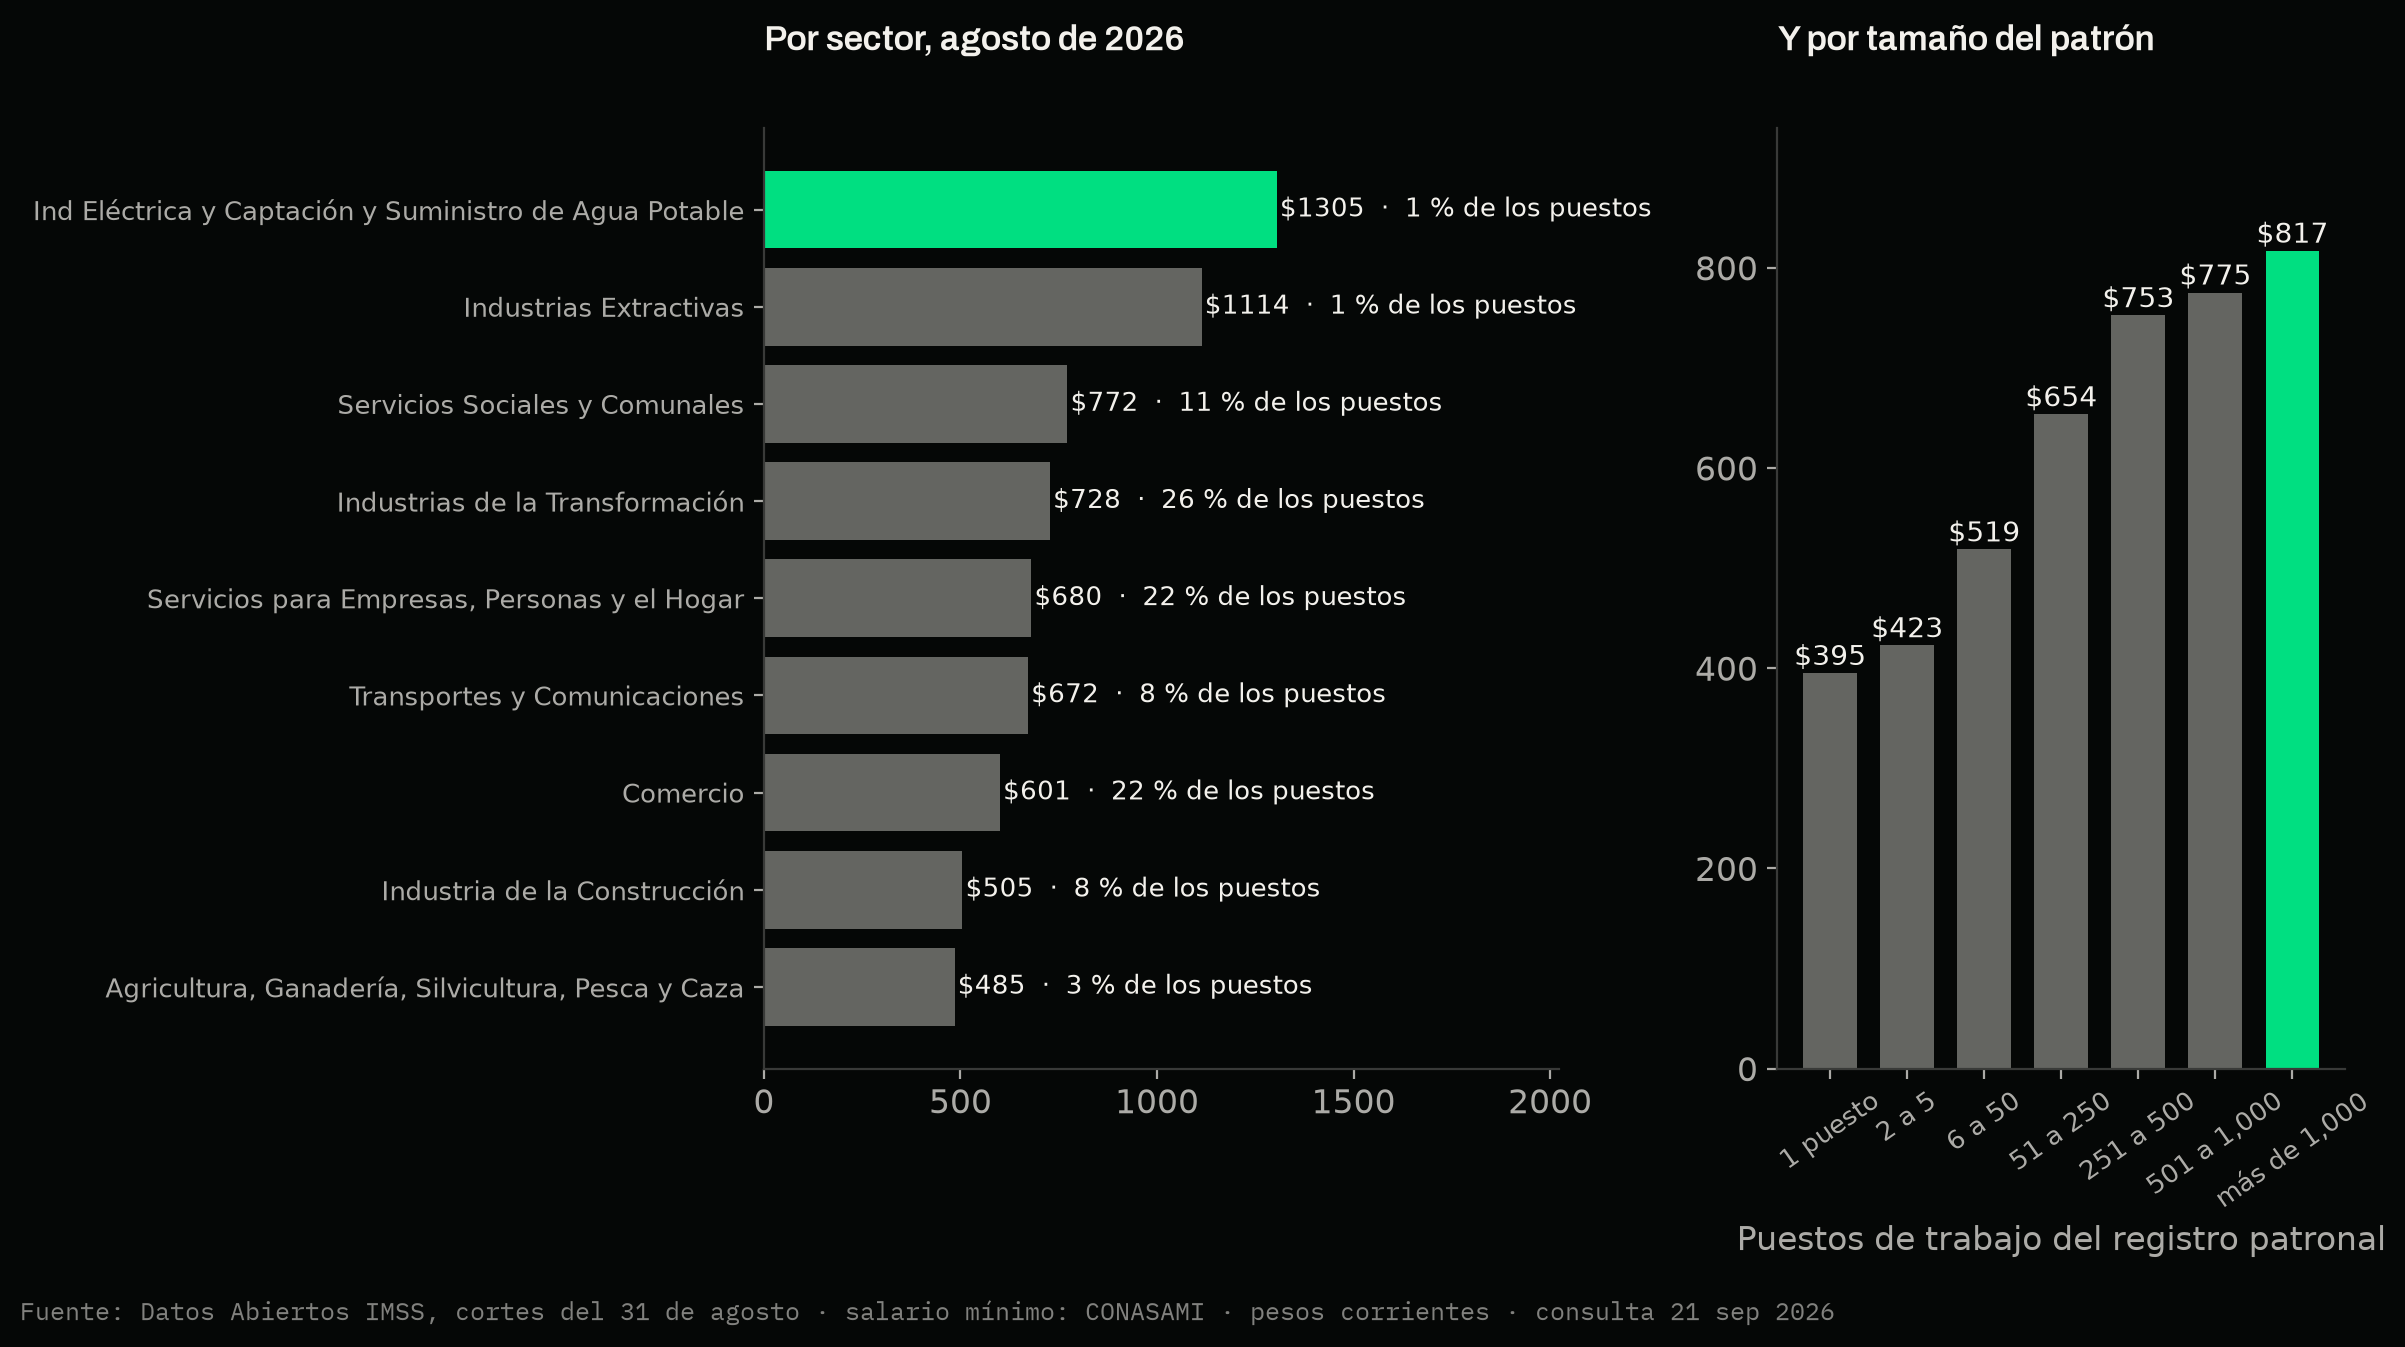

In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 6.75), gridspec_kw={"width_ratios": [1.4, 1]})
s = por_sector.iloc[::-1]
a1.barh(s.index, s["sbc"], color=[PALETA["verde"] if v == s["sbc"].max() else PALETA["neutro"] for v in s["sbc"]])
for i, (v, p) in enumerate(zip(s["sbc"], s["puestos_%"])):
    a1.text(v + 8, i, f"${v:.0f}  ·  {p:.0f} % de los puestos", va="center", fontsize=9.5, color=PALETA["tinta"])
a1.set_xlim(0, s["sbc"].max() * 1.55)
a1.tick_params(axis="y", labelsize=9.5)
titulo(a1, f"Por sector, agosto de {ULTIMO}", 12.5)
tt = por_tam.rename(index=TAMANOS)
a2.bar(tt.index, tt["sbc"], color=[PALETA["verde"] if v == tt["sbc"].max() else PALETA["neutro"] for v in tt["sbc"]], width=0.7)
for i, v in enumerate(tt["sbc"]):
    a2.text(i, v + 8, f"${v:.0f}", ha="center", fontsize=10, color=PALETA["tinta"])
a2.set_ylim(0, tt["sbc"].max() * 1.15)
a2.tick_params(axis="x", labelsize=9.5, rotation=35)
a2.set_xlabel("Puestos de trabajo del registro patronal")
titulo(a2, "Y por tamaño del patrón", 12.5)
pie(fig)
plt.tight_layout(rect=(0, 0.03, 1, 1), w_pad=3)
plt.show()

## 5. Los trabajadores de plataformas digitales

Desde la reforma de 2025 las plataformas registran a sus repartidores y conductores en el IMSS. La columna `ptpd` los identifica en el corte de 2026.

In [15]:
plat = leer("plataforma")
p = plat[plat.anio == ULTIMO].dropna(subset=["ptpd"]).set_index("ptpd")
p["sbc"] = p["masa_sal_ta"] / p["ta_sal"]
if 1 in p.index:
    print(f"Plataformas digitales {ULTIMO}: {p.loc[1, 'ta']:,} puestos, SBC ${p.loc[1, 'sbc']:.0f} · resto: ${p.loc[0, 'sbc']:.0f} · cociente {p.loc[1, 'sbc'] / p.loc[0, 'sbc']:.2f}")
p[["ta", "ta_sal", "sbc"]].round(1)

Plataformas digitales 2026: 199,454 puestos, SBC $429 · resto: $675 · cociente 0.63


,ta,ta_sal,sbc
ptpd,,,
0.0,22599019,22539555,675.2
1.0,199454,199454,428.6


## 6. Advertencias antes de citar estas cifras

- **Solo empleo formal afiliado al IMSS.** No están los trabajadores del Estado (ISSSTE), ni los informales, que son más de la mitad de la población ocupada según la ENOE del INEGI.
- **Salario topado.** El salario base de cotización se registra hasta 25 UMA (sección 1). Todo promedio de este notebook es una cota inferior; por eso cada uno va acompañado de la mediana, que el tope no toca.
- **Cifras nominales.** No se deflactan. La comparación relevante es contra el salario mínimo del mismo año, que sí se hace.
- **Estado del registro patronal.** Un puesto cuenta donde el patrón está registrado, no donde trabaja la persona.
- **Salario base de cotización, no neto.** Incluye prestaciones que integran salario y excluye lo que la ley excluye; no es lo que llega a la cuenta.